# Notebook 6 — SOLUTION

## Short version

**Nothing changed.** For every neuron, baseline and response were drawn from the
*same* firing rate. The mean fold-change is above 1 purely because **averaging
ratios is biased** when the denominator (the baseline) is noisy. Dividing by a
small, noisily-estimated baseline produces a heavy right tail (a neuron that by
chance had a low baseline gets a huge fold-change), so the *mean* fold-change is
pulled above 1 even though the typical (median) neuron is at ~1. This is
Jensen's inequality: E[post/pre] > E[post]/E[pre] when pre is variable.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams['font.family']       = 'Arial'
plt.rcParams['font.sans-serif']   = ['Arial', 'DejaVu Sans']
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['pdf.fonttype']      = 42
plt.rcParams['ps.fonttype']       = 42

# We intentionally divide by (occasionally zero) baselines below and handle the
# resulting non-finite values with np.isfinite; silence the expected warning.
np.seterr(divide='ignore', invalid='ignore')


{'divide': 'warn', 'over': 'warn', 'under': 'ignore', 'invalid': 'warn'}

In [2]:
d = np.load('data/data.npz')
pre_counts = d['pre_counts']       # (neurons, trials) spike counts, baseline window
post_counts = d['post_counts']     # (neurons, trials) spike counts, response window
duration = float(d['duration'])    # s per window
n_neurons, n_trials = pre_counts.shape
pre_rate  = pre_counts.mean(1) / duration      # per-neuron mean baseline rate (spikes/s)
post_rate = post_counts.mean(1) / duration     # per-neuron mean response rate
print(f'{n_neurons} neurons, {n_trials} trials per window')


200 neurons, 5 trials per window


## Evidence 1 — The bias lives in the low-baseline neurons

Plot each neuron's fold-change against its baseline rate. The neurons dragging
the mean up are exactly those with small (poorly-estimated) baselines; the
fold-change distribution has a long right tail, so the mean sits well above the
median (~1).


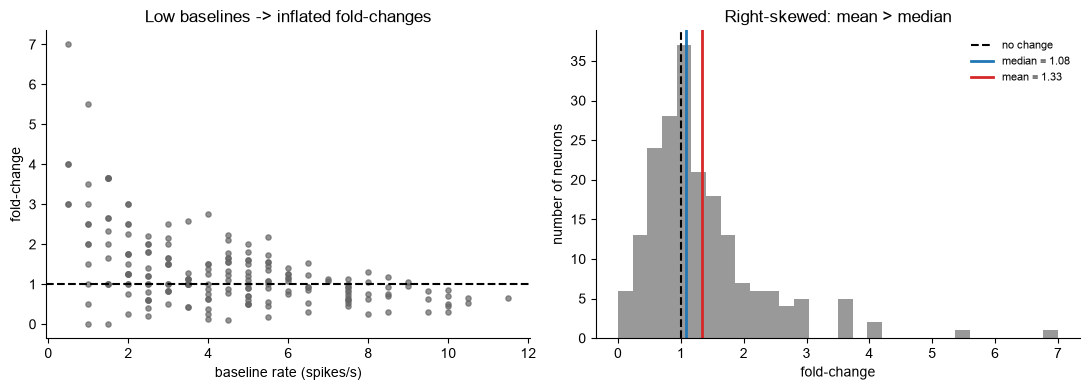

In [3]:
fold = post_rate / pre_rate
ok = np.isfinite(fold)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].scatter(pre_rate[ok], fold[ok], s=14, color='0.4', alpha=0.7)
axes[0].axhline(1.0, color='k', ls='--')
axes[0].set_xlabel('baseline rate (spikes/s)'); axes[0].set_ylabel('fold-change')
axes[0].set_title('Low baselines -> inflated fold-changes')

axes[1].hist(fold[ok], bins=30, color='0.6')
axes[1].axvline(1.0, color='k', ls='--', label='no change')
axes[1].axvline(np.median(fold[ok]), color='tab:blue', lw=2, label=f'median = {np.median(fold[ok]):.2f}')
axes[1].axvline(fold[ok].mean(), color='tab:red', lw=2, label=f'mean = {fold[ok].mean():.2f}')
axes[1].set_xlabel('fold-change'); axes[1].set_ylabel('number of neurons')
axes[1].set_title('Right-skewed: mean > median'); axes[1].legend(frameon=False, fontsize=8)
plt.tight_layout(); plt.show()


## Evidence 2 — Bias-free summaries show no change

Every summary that avoids averaging per-neuron ratios agrees there is no change:
the mean *difference* (post - pre) is ~0, the ratio of population means is ~1,
and the mean *log* fold-change is ~0.


In [4]:
fold = post_rate / pre_rate; ok = np.isfinite(fold) & (fold > 0)
print(f'mean fold-change (biased)     : {fold[np.isfinite(fold)].mean():.3f}')
print(f'median fold-change            : {np.median(fold[np.isfinite(fold)]):.3f}')
print(f'ratio of population means     : {post_rate.mean()/pre_rate.mean():.3f}')
print(f'mean difference (post - pre)  : {(post_rate - pre_rate).mean():+.3f} spikes/s')
print(f'mean log2 fold-change         : {np.log2(fold[ok]).mean():+.3f}')


mean fold-change (biased)     : 1.330
median fold-change            : 1.083
ratio of population means     : 1.067
mean difference (post - pre)  : +0.292 spikes/s
mean log2 fold-change         : +0.121


## Evidence 3 — The bias is estimation noise: it shrinks with more baseline data

The inflation comes from a *noisy* baseline. Re-estimate each baseline from more
trials (less noise) and the mean fold-change falls toward 1 -- confirming there
was never a real change, only division by noisy denominators.


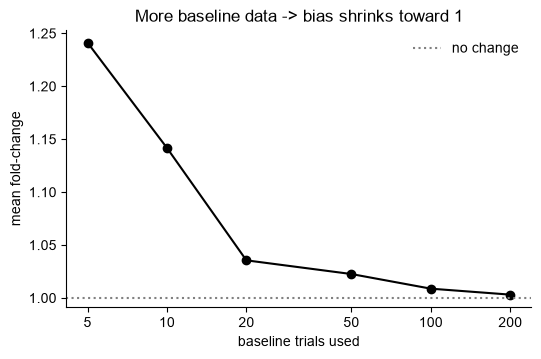

In [5]:
gt = np.load('data/ground_truth.npz', allow_pickle=True)
true_rate = gt['true_rate']; rng = np.random.default_rng(0)

trials_list = [5, 10, 20, 50, 100, 200]
mean_fold = []
for nt in trials_list:
    lam = true_rate[:, None] * duration
    pre  = rng.poisson(lam, (n_neurons, nt)).mean(1) / duration
    post = rng.poisson(lam, (n_neurons, nt)).mean(1) / duration
    f = post / pre
    mean_fold.append(f[np.isfinite(f)].mean())

fig, ax = plt.subplots(figsize=(6, 3.6))
ax.plot(trials_list, mean_fold, 'o-', color='k')
ax.axhline(1.0, color='0.5', ls=':', label='no change')
ax.set_xscale('log', base=2); ax.set_xticks(trials_list); ax.set_xticklabels(trials_list)
ax.set_xlabel('baseline trials used'); ax.set_ylabel('mean fold-change')
ax.set_title('More baseline data -> bias shrinks toward 1')
ax.legend(frameon=False)
plt.show()


## The lesson

- **Averaging ratios is biased when the denominator is noisy.** A per-neuron
  fold-change divides by a noisily-estimated baseline; small baselines blow up,
  the distribution is right-skewed, and the *mean* fold-change exceeds 1 even
  with no real change (Jensen's inequality, E[X/Y] > E[X]/E[Y]).
- **Prefer summaries that don't average ratios.** Report the mean *difference*,
  the ratio of means, or average in the *log* domain; use the median if you must
  average fold-changes; and estimate baselines from enough data.
- **Beware any per-unit normalization that divides by a small, noisy number**
  (baseline normalization, %-change, indices like (a-b)/(a+b)) -- the same bias
  appears throughout.
